## 1. Librerías

In [1]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## 2. Datos

Usamos los archivos que dejó el notebook 02: ya vienen con `get_dummies` y escalados con `MinMaxScaler` (ajustado solo con train).

In [2]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

X_train = train.drop(columns="Churn").values.astype("float32")
y_train = train["Churn"].values
X_test = test.drop(columns="Churn").values.astype("float32")
y_test = test["Churn"].values

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn en train:", round(y_train.mean(), 3))

Train: (5625, 24)  Test: (1407, 24)
Churn en train: 0.269


### 2.1 Desbalance de clases

Solo cerca del 27 % de los clientes se van. El Modelo 1 compensa esto con `class_weight`, porque su trabajo es decidir sí o no y no debe dejar escapar a los que se van.

El Modelo 2 **no usa `class_weight`**, a propósito. `class_weight` hace que la red le dé más importancia a los clientes que se van, y eso **infla las probabilidades**: el modelo diría que se va más gente de la que realmente se va. Para un modelo cuyo resultado es la probabilidad, eso es un error. En la sección 3.5 lo comprobamos con los datos.

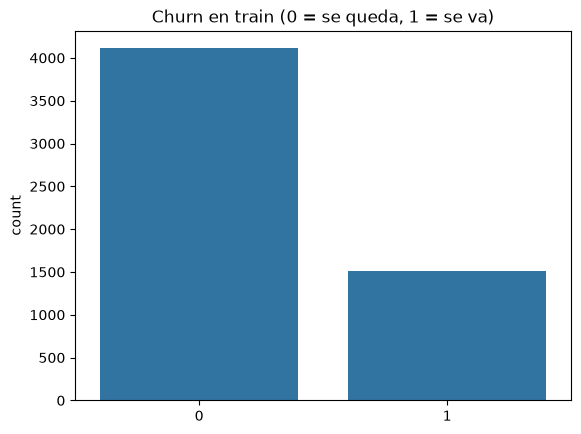

In [3]:
sns.countplot(x=y_train)
plt.title("Churn en train (0 = se queda, 1 = se va)")
plt.show()

### 2.2 Validación

Entrenamos con `validation_split=0.2`: Keras separa el **último 20 %** de `X_train` para validar y no entrena con esas filas. Guardamos esas mismas filas aparte, porque las usamos para comparar configuraciones y para definir los umbrales.

El conjunto de validación cumple tres funciones (EarlyStopping, elegir la configuración y fijar los umbrales). El **test no se usa para nada de eso**: solo para la evaluación final.

In [4]:
VALIDATION_SPLIT = 0.2
corte = int(math.floor(len(X_train) * (1 - VALIDATION_SPLIT)))  # mismo corte que hace Keras
X_val, y_val = X_train[corte:], y_train[corte:]
print("Filas de validación:", len(X_val))

Filas de validación: 1125


## 3. Arquitectura del Modelo 2

Seguimos los criterios vistos en clase (Semana 03, "Claves para crear redes neuronales efectivas"):

- **Capas ocultas:** se recomienda empezar con 2 o 3. Usamos **3**, en forma de embudo.
- **Neuronas por capa:** proporcionales al número de variables. Tenemos 24 variables de entrada, así que usamos **48 → 24 → 12** (el doble, igual y la mitad).
- **Activación:** ReLU en las capas ocultas, que es la recomendada por defecto porque evita el desvanecimiento del gradiente.
- **Capa de salida:** 1 neurona **sigmoid**, la que corresponde a clasificación binaria. Su salida, entre 0 y 1, es justamente la probabilidad de churn.
- **Optimizador:** Adam (gradiente descendente adaptativo). **Pérdida:** `binary_crossentropy`.
- **Épocas:** las necesarias hasta justo antes del sobreajuste. De eso se encarga EarlyStopping. Los datos pasan en batches (32 por defecto).

**Diferencias con el Modelo 1:** la arquitectura es distinta y, además, este modelo se entrena **sin `class_weight`** porque su objetivo es una probabilidad real y no una decisión sí/no.

**Métricas:**
- `val_loss` (`binary_crossentropy`): es la métrica que premia que las probabilidades sean correctas, así que es la que usamos para EarlyStopping y para elegir la configuración.
- **AUC**, que va de 0.5 (azar) a 1 (perfecto). Mide qué tan bien el modelo ordena a los clientes de mayor a menor riesgo.

In [5]:
num_entradas = X_train.shape[1]

def crear_modelo(dropout=0.0, semilla=101):
    tf.keras.utils.set_random_seed(semilla)  # para que los resultados se puedan repetir
    model = Sequential()
    model.add(Input(shape=(num_entradas,)))
    for neuronas in [48, 24, 12]:
        model.add(Dense(units=neuronas, activation="relu"))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(units=1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", optimizer="adam",
                  metrics=[tf.keras.metrics.AUC(name="auc")])
    return model

crear_modelo(0.3).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor="val_loss", mode="min", verbose=1,
                           patience=25, restore_best_weights=True)

### 3.1 Configuración A: sin Dropout

Epoch 30: early stopping


Restoring model weights from the end of the best epoch: 5.


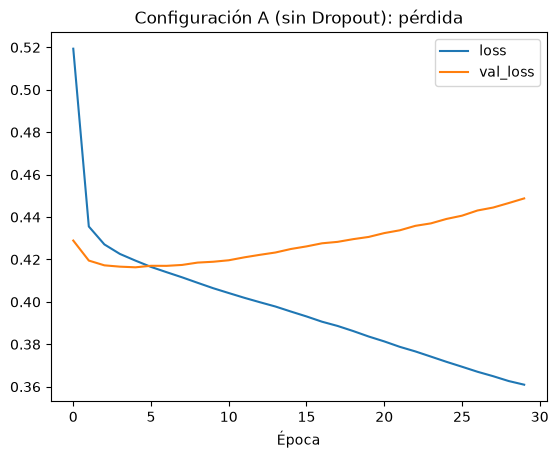

Épocas entrenadas: 30 | mejor época: 5


In [7]:
model_a = crear_modelo(dropout=0.0)
model_a.fit(x=X_train, y=y_train, epochs=600,
            validation_split=VALIDATION_SPLIT,
            callbacks=[early_stop], verbose=0)

historial_a = pd.DataFrame(model_a.history.history)
historial_a[["loss", "val_loss"]].plot(title="Configuración A (sin Dropout): pérdida")
plt.xlabel("Época")
plt.show()
print("Épocas entrenadas:", len(historial_a), "| mejor época:", historial_a["val_loss"].idxmin() + 1)

### 3.2 Configuración B: con Dropout (0.3)

Epoch 35: early stopping


Restoring model weights from the end of the best epoch: 10.


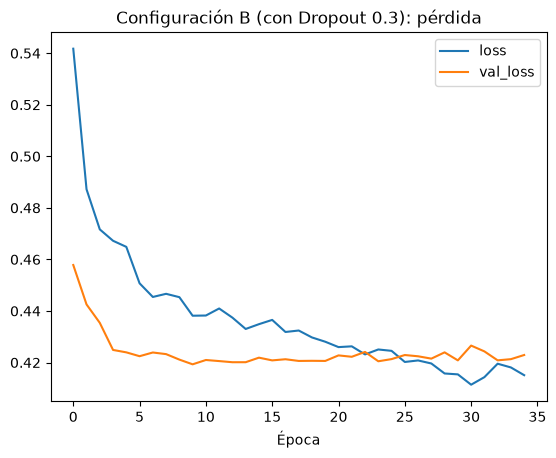

Épocas entrenadas: 35 | mejor época: 10


In [8]:
model_b = crear_modelo(dropout=0.3)
model_b.fit(x=X_train, y=y_train, epochs=600,
            validation_split=VALIDATION_SPLIT,
            callbacks=[early_stop], verbose=0)

historial_b = pd.DataFrame(model_b.history.history)
historial_b[["loss", "val_loss"]].plot(title="Configuración B (con Dropout 0.3): pérdida")
plt.xlabel("Época")
plt.show()
print("Épocas entrenadas:", len(historial_b), "| mejor época:", historial_b["val_loss"].idxmin() + 1)

### 3.3 Comparación

Comparamos con los datos de **validación** (no con test).

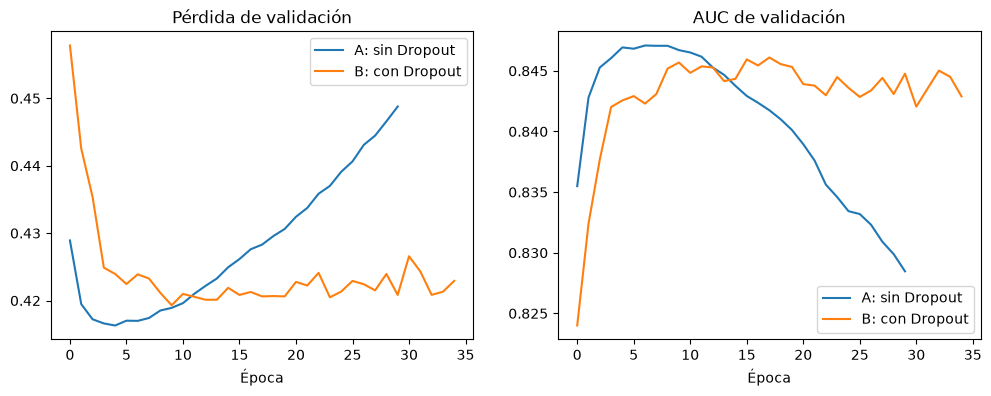

,Configuración,Mejor época,Mejor val_loss,Subida de val_loss después del mínimo,AUC validación
0,A: sin Dropout,5,0.4163,0.0325,0.847
1,B: con Dropout 0.3,10,0.4193,0.0036,0.846


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(historial_a["val_loss"], label="A: sin Dropout")
ax[0].plot(historial_b["val_loss"], label="B: con Dropout")
ax[0].set_title("Pérdida de validación")
ax[0].set_xlabel("Época")
ax[0].legend()
ax[1].plot(historial_a["val_auc"], label="A: sin Dropout")
ax[1].plot(historial_b["val_auc"], label="B: con Dropout")
ax[1].set_title("AUC de validación")
ax[1].set_xlabel("Época")
ax[1].legend()
plt.show()

def resumen(nombre, historial, model):
    mejor = historial["val_loss"].idxmin()
    return {
        "Configuración": nombre,
        "Mejor época": mejor + 1,
        "Mejor val_loss": historial["val_loss"].min(),
        "Subida de val_loss después del mínimo": historial["val_loss"].iloc[-1] - historial["val_loss"].min(),
        "AUC validación": roc_auc_score(y_val, model.predict(X_val, verbose=0).ravel()),
    }

comparacion = pd.DataFrame([resumen("A: sin Dropout", historial_a, model_a),
                            resumen("B: con Dropout 0.3", historial_b, model_b)]).round(4)
comparacion

**Qué vemos.** Las dos configuraciones llegan prácticamente al mismo punto: A logra una `val_loss` mínima de ≈ 0.416 en la época 5 y B de ≈ 0.419 en la época 10. El AUC es casi igual (≈ 0.847 y ≈ 0.846).

La diferencia está en lo que pasa después del mínimo:
- **Sin Dropout, A se sobreajusta rápido.** La pérdida de entrenamiento sigue bajando mientras la de validación sube (≈ +0.03 en las 25 épocas siguientes).
- **Con Dropout, B se mantiene casi estable** (≈ +0.004).

Es decir, Dropout cumple su función de frenar el sobreajuste, pero no mejora el mejor resultado.

### 3.4 ¿La diferencia es real o es suerte?

Los pesos iniciales de la red son aleatorios, así que un solo entrenamiento puede ganar por casualidad. Repetimos el entrenamiento con 5 semillas distintas para cada configuración y miramos el promedio.

In [10]:
filas = []
for semilla in [1, 2, 3, 4, 5]:
    for dropout in [0.0, 0.3]:
        m = crear_modelo(dropout=dropout, semilla=semilla)
        m.fit(x=X_train, y=y_train, epochs=600, validation_split=VALIDATION_SPLIT,
              callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=25,
                                       restore_best_weights=True)], verbose=0)
        h = pd.DataFrame(m.history.history)
        filas.append({"Semilla": semilla, "Dropout": dropout,
                      "Mejor val_loss": h["val_loss"].min(),
                      "AUC validación": roc_auc_score(y_val, m.predict(X_val, verbose=0).ravel())})

semillas = pd.DataFrame(filas)
semillas.pivot(index="Semilla", columns="Dropout", values="Mejor val_loss").round(4)

Dropout,0.0,0.3
Semilla,,
1,0.4137,0.4133
2,0.4075,0.4132
3,0.4100,0.4107
4,0.4085,0.4148
5,0.4038,0.4125


In [11]:
semillas.groupby("Dropout")[["Mejor val_loss", "AUC validación"]].agg(["mean", "std"]).round(4)

Mejor val_loss         AUC validación        
                  mean     std           mean     std
Dropout                                              
0.0             0.4087  0.0036         0.8513  0.0025
0.3             0.4129  0.0015         0.8500  0.0015

**Resultado.** Sin Dropout, la `val_loss` mínima es un poco mejor en 4 de las 5 semillas y también en promedio (≈ 0.409 contra ≈ 0.413). El AUC promedio también es apenas mayor. La diferencia es pequeña, pero se repite, así que no es suerte.

**Elegimos A (sin Dropout).** Su riesgo es que se sobreajusta rápido, pero EarlyStopping con `restore_best_weights=True` lo controla: detiene el entrenamiento y devuelve los pesos de la mejor época. Dropout hace el entrenamiento más estable, pero en este problema no mejora las probabilidades. *(Al volver a ejecutar en otra computadora, los valores pueden variar un poco.)*

In [12]:
model = model_a  # configuración elegida

### 3.5 ¿Por qué el Modelo 2 no usa `class_weight`?

Entrenamos la configuración elegida **con** `class_weight` y comparamos sus probabilidades con las del modelo elegido.

In [13]:
pesos = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
model_cw = crear_modelo(dropout=0.0)
model_cw.fit(x=X_train, y=y_train, epochs=600, validation_split=VALIDATION_SPLIT,
             class_weight={0: pesos[0], 1: pesos[1]},
             callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=25,
                                      restore_best_weights=True)], verbose=0)

prob_sin_cw = model.predict(X_val, verbose=0).ravel()
prob_con_cw = model_cw.predict(X_val, verbose=0).ravel()
pd.DataFrame({
    "Modelo": ["Sin class_weight (elegido)", "Con class_weight"],
    "Probabilidad media predicha": [prob_sin_cw.mean(), prob_con_cw.mean()],
    "Churn real en validación": [y_val.mean(), y_val.mean()],
    "AUC validación": [roc_auc_score(y_val, prob_sin_cw), roc_auc_score(y_val, prob_con_cw)],
}).round(3)

,Modelo,Probabilidad media predicha,Churn real en validación,AUC validación
0,Sin class_weight (elegido),0.287,0.262,0.847
1,Con class_weight,0.423,0.262,0.842


**Resultado.** Con `class_weight`, el modelo predice en promedio una probabilidad de churn de ≈ 42 %, cuando en realidad se va el ≈ 26 %: las probabilidades quedan infladas. Además, no ordena mejor a los clientes (AUC ≈ 0.842 contra ≈ 0.847). Sin `class_weight`, la probabilidad media (≈ 29 %) queda cerca de la real.

**Conclusión:** `class_weight` tiene sentido en el Modelo 1, que decide sí o no y no debe dejar escapar a los que se van. No lo tiene en el Modelo 2, cuyo resultado es la probabilidad.

In [14]:
# Guardamos los historiales para el notebook 05 (comparación de modelos) #
historial_a.to_csv("../models/historial_modelo2_sin_dropout.csv", index=False)
historial_b.to_csv("../models/historial_modelo2_con_dropout.csv", index=False)

## 4. Umbrales de riesgo

Primero comprobamos en validación que las probabilidades sean reales: en cada rango, la probabilidad que da el modelo debería parecerse al porcentaje de clientes que realmente se fue.

In [15]:
prob_val = model.predict(X_val, verbose=0).ravel()

rangos = pd.cut(prob_val, bins=np.arange(0, 1.01, 0.1), include_lowest=True)
tabla_rangos = (pd.DataFrame({"rango": rangos, "prob": prob_val, "churn_real": y_val})
                .groupby("rango", observed=False)
                .agg(clientes=("churn_real", "size"),
                     prob_media_predicha=("prob", "mean"),
                     tasa_churn_real=("churn_real", "mean"))
                .round(3))
tabla_rangos

,clientes,prob_media_predicha,tasa_churn_real
rango,,,
"(-0.001, 0.1]",399,0.035,0.028
"(0.1, 0.2]",155,0.144,0.123
"(0.2, 0.3]",112,0.247,0.214
"(0.3, 0.4]",79,0.352,0.392
"(0.4, 0.5]",88,0.453,0.352
"(0.5, 0.6]",88,0.546,0.432
"(0.6, 0.7]",103,0.652,0.612
"(0.7, 0.8]",93,0.744,0.774
"(0.8, 0.9]",8,0.807,0.750


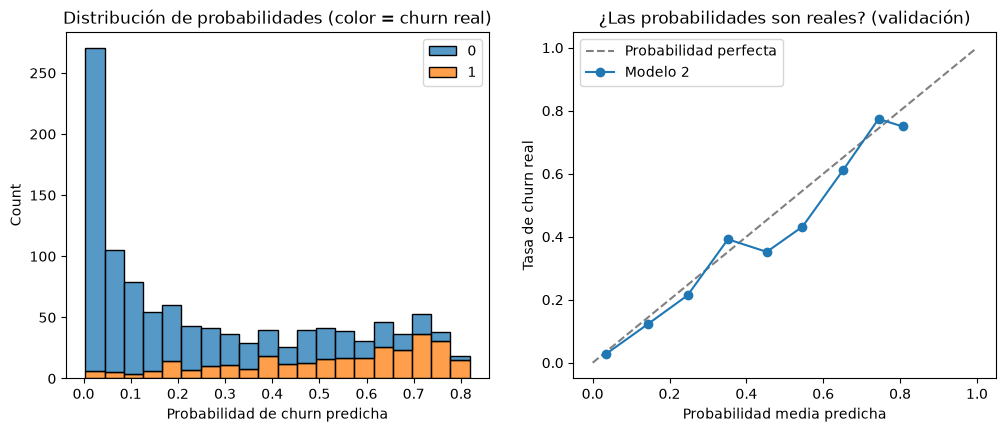

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(x=prob_val, hue=y_val, bins=20, multiple="stack", ax=ax[0])
ax[0].set_xlabel("Probabilidad de churn predicha")
ax[0].set_title("Distribución de probabilidades (color = churn real)")

con_datos = tabla_rangos.dropna()
ax[1].plot([0, 1], [0, 1], "--", color="gray", label="Probabilidad perfecta")
ax[1].plot(con_datos["prob_media_predicha"], con_datos["tasa_churn_real"], marker="o", label="Modelo 2")
ax[1].set_xlabel("Probabilidad media predicha")
ax[1].set_ylabel("Tasa de churn real")
ax[1].set_title("¿Las probabilidades son reales? (validación)")
ax[1].legend()
plt.show()

**Las probabilidades son reales.** En casi todos los rangos, la probabilidad que da el modelo se parece a la tasa real: la línea queda cerca de la diagonal. Entre 0.4 y 0.6 el modelo exagera un poco (dice ≈ 45–55 % y se va ≈ 35–43 %). Por eso los umbrales se pueden leer directamente como probabilidades.

**Umbrales elegidos**

| Nivel | Probabilidad | Churn real (validación) | Significado | Acción |
|---|---|---|---|---|
| Bajo | < 0.10 | ≈ 3 % | Casi nadie se va | Ninguna |
| Medio | 0.10 – 0.30 | ≈ 16 % | Por debajo del promedio de la empresa (≈ 27 %) | Seguimiento sin costo |
| Alto | 0.30 – 0.60 | ≈ 39 % | Por encima del promedio | Oferta de retención |
| Crítico | ≥ 0.60 | ≈ 69 % | Es más probable que se vaya a que se quede | Contacto inmediato |

**Por qué esos cortes:**
- **0.10:** por debajo, el churn real es mínimo (≈ 3 %). Son clientes que no requieren atención.
- **0.30:** es el promedio de churn de la empresa (≈ 27 %), redondeado. Además, en la sección 7.1 se ve que es el **punto de equilibrio económico**: desde ≈ 0.30, ofrecer retención se paga sola.
- **0.60:** a partir de aquí se van 6 de cada 10 clientes o más. Requieren contacto inmediato.

In [17]:
UMBRALES = {"medio": 0.1, "alto": 0.3, "critico": 0.6}
NIVELES = ["Bajo", "Medio", "Alto", "Crítico"]

def nivel_riesgo(probabilidad):
    if probabilidad >= UMBRALES["critico"]:
        return "Crítico"
    if probabilidad >= UMBRALES["alto"]:
        return "Alto"
    if probabilidad >= UMBRALES["medio"]:
        return "Medio"
    return "Bajo"

niveles_val = pd.Series([nivel_riesgo(p) for p in prob_val])
(pd.DataFrame({"nivel": niveles_val, "churn_real": y_val})
   .groupby("nivel")["churn_real"].agg(clientes="count", tasa_churn_real="mean")
   .reindex(NIVELES).round(3))

,clientes,tasa_churn_real
nivel,,
Bajo,399,0.028
Medio,267,0.161
Alto,255,0.392
Crítico,204,0.691


## 5. Evaluación final con test

Es la única vez que usamos el conjunto de prueba.

In [18]:
prob_test = model.predict(X_test, verbose=0).ravel()
pred_test = (prob_test > 0.5).astype("int32")

print(classification_report(y_test, pred_test, target_names=["Se queda", "Se va"]))
print("AUC test:", round(roc_auc_score(y_test, prob_test), 4))
print("Probabilidad media predicha:", round(prob_test.mean(), 3), "| churn real:", round(y_test.mean(), 3))

              precision    recall  f1-score   support

    Se queda       0.87      0.86      0.86      1052
       Se va       0.59      0.61      0.60       355

    accuracy                           0.80      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.80      0.80      0.80      1407

AUC test: 0.8397
Probabilidad media predicha: 0.285 | churn real: 0.252


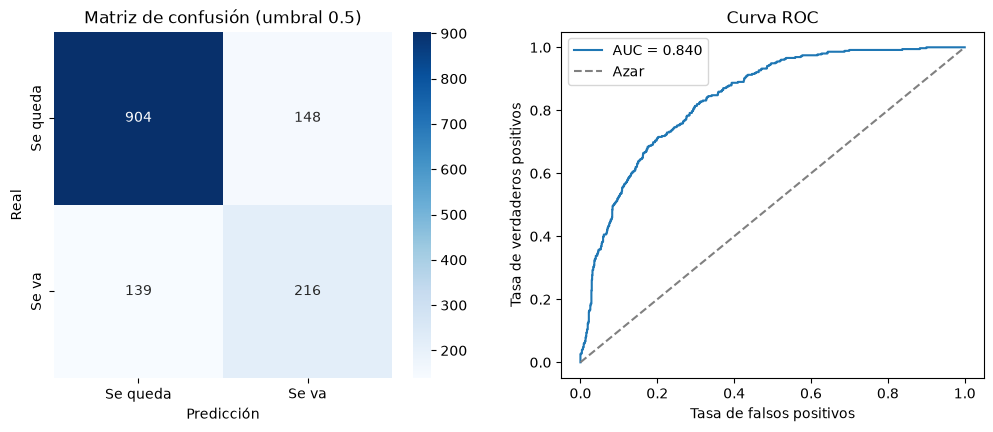

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(confusion_matrix(y_test, pred_test), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Se queda", "Se va"], yticklabels=["Se queda", "Se va"], ax=ax[0])
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Real")
ax[0].set_title("Matriz de confusión (umbral 0.5)")

fpr, tpr, _ = roc_curve(y_test, prob_test)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, prob_test):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray", label="Azar")
ax[1].set_xlabel("Tasa de falsos positivos")
ax[1].set_ylabel("Tasa de verdaderos positivos")
ax[1].set_title("Curva ROC")
ax[1].legend()
plt.show()

**Lectura.**
- **AUC en test ≈ 0.84:** el modelo ordena bien a los clientes de mayor a menor riesgo.
- **Probabilidades:** la media predicha (≈ 28.5 %) queda cerca del churn real del test (≈ 25 %). Parte de la diferencia viene de que el test tiene menos churn que train (25 % contra 27 %), porque la división del notebook 02 no fue estratificada.
- **Con el umbral 0.5:** acierta el 80 % de los casos y detecta ≈ 61 % de los clientes que se van, con una precisión de ≈ 59 %.

El Modelo 2 no se usa con ese corte, sino con los niveles de riesgo. Incluimos el reporte porque la rúbrica lo pide. La decisión sí/no que prioriza detectar a los que se van le corresponde al Modelo 1, que usa `class_weight`.

Revisamos que los niveles definidos en validación se mantengan en test:

In [20]:
niveles_test = pd.Series([nivel_riesgo(p) for p in prob_test])
resumen_niveles = (pd.DataFrame({"nivel": niveles_test, "prob": prob_test, "churn_real": y_test})
                   .groupby("nivel")
                   .agg(clientes=("churn_real", "size"),
                        prob_media_predicha=("prob", "mean"),
                        tasa_churn_real=("churn_real", "mean"))
                   .reindex(NIVELES))
resumen_niveles["% de clientes"] = resumen_niveles["clientes"] / len(y_test)
resumen_niveles.round(3)

,clientes,prob_media_predicha,tasa_churn_real,% de clientes
nivel,,,,
Bajo,507,0.038,0.028,0.360
Medio,340,0.194,0.200,0.242
Alto,305,0.449,0.344,0.217
Crítico,255,0.700,0.659,0.181


## 6. Guardar modelo y umbrales

`umbrales_riesgo.json` lo usan la API (`/predict/risk_score`) y el dashboard, para que los tres usen exactamente los mismos niveles.

In [21]:
model.save("../models/model2.keras")

with open("../models/umbrales_riesgo.json", "w", encoding="utf-8") as f:
    json.dump({"umbrales": UMBRALES, "niveles": NIVELES}, f, indent=2)  # en ASCII: se lee bien con cualquier codificación

print("Guardados: models/model2.keras y models/umbrales_riesgo.json")

Guardados: models/model2.keras y models/umbrales_riesgo.json


## 7. Análisis de ROI de estrategias de retención

**Pregunta:** si le ofrecemos un beneficio a los clientes para que no se vayan, ¿a quiénes conviene ofrecérselo?

### Supuestos
Están todos en la celda siguiente, así que se pueden cambiar.
- **Oferta de retención:** un mes gratis. Cuesta el `MonthlyCharges` del cliente (ingreso que se deja de cobrar), más $5 por el contacto (llamada o correo).
- **Tasa de éxito:** el 30 % de los clientes que se iban a ir y reciben la oferta se quedan.
- **Ingreso recuperado:** si un cliente se queda, la empresa sigue cobrando 12 meses de su `MonthlyCharges`.
- A un cliente que **no se iba a ir** también se le da la oferta si cae en un nivel contactado. Ese costo se pierde (son los **falsos positivos**).

**Limitación:** todo está medido en **ingresos**, no en utilidad. No conocemos el margen de ganancia de la empresa, así que los montos reales serían menores. La comparación entre estrategias sí es válida.

### Cálculo
- Costo = Σ (MonthlyCharges + 5) de todos los clientes contactados
- Ingreso recuperado = Σ (MonthlyCharges × 12 × 0.30) de los contactados que realmente se iban (**verdaderos positivos**)
- Resultado neto = Ingreso recuperado − Costo
- ROI = Resultado neto / Costo

Usamos el conjunto de test (1 407 clientes) como si fuera la cartera de un mes.

In [22]:
COSTO_CONTACTO = 5       # USD por cliente contactado
MESES_OFERTA = 1         # meses gratis que se regalan
TASA_EXITO = 0.30        # % de clientes en fuga que se retienen gracias a la oferta
MESES_VALOR = 12         # meses de ingreso que se recuperan si el cliente se queda

# MonthlyCharges está escalado: lo devolvemos a dólares con el scaler del notebook 02 #
scaler = joblib.load("../models/scaler.pkl")
columnas = joblib.load("../models/columnas.pkl")
X_test_real = pd.DataFrame(scaler.inverse_transform(test[columnas]), columns=columnas)

cartera = pd.DataFrame({
    "cargo_mensual": X_test_real["MonthlyCharges"].values,
    "prob": prob_test,
    "churn_real": y_test,
    "nivel": niveles_test.values,
})
cartera.groupby("nivel")["cargo_mensual"].mean().reindex(NIVELES).round(2)

nivel
Bajo       54.58
Medio      58.88
Alto       72.22
Crítico    82.98
Name: cargo_mensual, dtype: float64

### 7.1 ¿Desde qué probabilidad conviene contactar a un cliente?

Como las probabilidades del Modelo 2 son reales, podemos calcularlo. Contactar a un cliente conviene si lo que se espera recuperar supera lo que cuesta la oferta:

**probabilidad × 0.30 × 12 × MonthlyCharges > MonthlyCharges + 5**

Despejando, el **punto de equilibrio** es: probabilidad > (MonthlyCharges + 5) / (0.30 × 12 × MonthlyCharges)

In [23]:
def punto_equilibrio(cargo_mensual, tasa_exito=TASA_EXITO):
    return (cargo_mensual * MESES_OFERTA + COSTO_CONTACTO) / (tasa_exito * MESES_VALOR * cargo_mensual)

equilibrio = punto_equilibrio(cartera["cargo_mensual"])
print("Punto de equilibrio para un cliente de $20/mes:", round(punto_equilibrio(20), 3))
print("Punto de equilibrio para un cliente de $65/mes:", round(punto_equilibrio(65), 3))
print("Punto de equilibrio para un cliente de $110/mes:", round(punto_equilibrio(110), 3))
print("Mediana en la cartera:", round(equilibrio.median(), 3))

Punto de equilibrio para un cliente de $20/mes: 0.347
Punto de equilibrio para un cliente de $65/mes: 0.299
Punto de equilibrio para un cliente de $110/mes: 0.29
Mediana en la cartera: 0.298


**Resultado.** Para casi cualquier cliente, el punto de equilibrio está alrededor de **0.30**: ≈ 0.35 para un cliente de $20/mes y ≈ 0.29 para uno de $110/mes. Con estos supuestos, ofrecer la retención conviene cuando la probabilidad de churn supera ≈ 0.30, que coincide con el umbral del nivel **Alto**.

### 7.2 Comparación de estrategias

In [24]:
def evaluar_estrategia(nombre, contactar, tasa_exito=TASA_EXITO):
    # contactar: True/False por cliente (¿le ofrecemos la retención?) #
    contactados = cartera[contactar]
    vp = contactados[contactados["churn_real"] == 1]   # se iban y los contactamos
    fp = contactados[contactados["churn_real"] == 0]   # no se iban y les dimos la oferta
    fn = cartera[(cartera["churn_real"] == 1) & ~contactar]

    costo = (contactados["cargo_mensual"] * MESES_OFERTA + COSTO_CONTACTO).sum()
    ingreso = (vp["cargo_mensual"] * MESES_VALOR * tasa_exito).sum()
    return {
        "Estrategia": nombre,
        "Contactados": len(contactados),
        "Se iban (VP)": len(vp),
        "No se iban (FP)": len(fp),
        "Fugas no atendidas (FN)": len(fn),
        "Costo $": round(costo),
        "Ingreso recuperado $": round(ingreso),
        "Resultado neto $": round(ingreso - costo),
        "ROI": round((ingreso - costo) / costo, 2) if costo > 0 else np.nan,  # sin contactados no hay ROI
    }

def estrategias(tasa_exito=TASA_EXITO):
    return {
        "Solo Crítico": cartera["nivel"].isin(["Crítico"]),
        "Crítico + Alto": cartera["nivel"].isin(["Crítico", "Alto"]),
        "Crítico + Alto + Medio": cartera["nivel"].isin(["Crítico", "Alto", "Medio"]),
        "Todos (sin modelo)": cartera["nivel"].isin(NIVELES),
        "Prob. > punto de equilibrio": cartera["prob"] > punto_equilibrio(cartera["cargo_mensual"], tasa_exito),
    }

roi = pd.DataFrame([evaluar_estrategia(n, c) for n, c in estrategias().items()])
roi

,Estrategia,Contactados,Se iban (VP),No se iban (FP),Fugas no atendidas (FN),Costo $,Ingreso recuperado $,Resultado neto $,ROI
0,Solo Crítico,255,168,87,187,22434,49679,27245,1.21
1,Crítico + Alto,560,273,287,82,45985,75889,29903,0.65
2,Crítico + Alto + Medio,900,341,559,14,67706,91388,23682,0.35
3,Todos (sin modelo),1407,355,1052,0,97910,95108,-2802,-0.03
4,Prob. > punto de equilibrio,562,276,286,79,46533,77047,30515,0.66


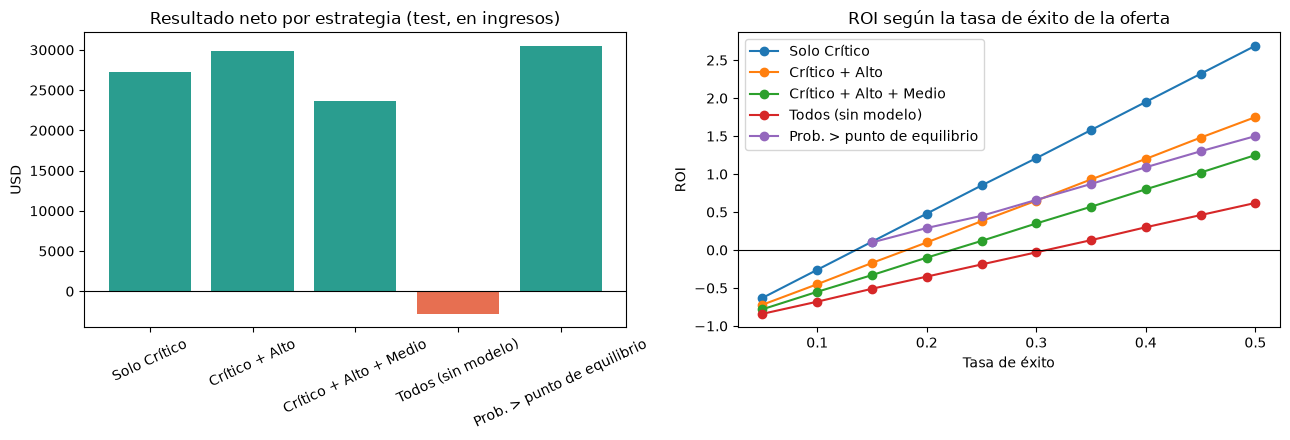

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(roi["Estrategia"], roi["Resultado neto $"],
          color=["#2a9d8f" if g > 0 else "#e76f51" for g in roi["Resultado neto $"]])
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].set_title("Resultado neto por estrategia (test, en ingresos)")
ax[0].set_ylabel("USD")
ax[0].tick_params(axis="x", rotation=25)

# Sensibilidad: ¿qué pasa si la oferta funciona mejor o peor de lo supuesto? #
tasas = np.arange(0.05, 0.55, 0.05)
for nombre in estrategias():
    rois = [evaluar_estrategia(nombre, estrategias(t)[nombre], t)["ROI"] for t in tasas]
    ax[1].plot(tasas, rois, marker="o", label=nombre)
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_title("ROI según la tasa de éxito de la oferta")
ax[1].set_xlabel("Tasa de éxito")
ax[1].set_ylabel("ROI")
ax[1].legend()
plt.tight_layout()
plt.show()

**Resultados** (test, tasa de éxito del 30 %):
- **Ofrecer a todos (sin modelo) pierde dinero** (ROI ≈ −3 %). La mayoría de los clientes no se iba a ir (1 052 falsos positivos).
- **Solo Crítico** tiene el **mejor ROI** (≈ 121 %): de 255 contactados, 168 realmente se iban. Pero deja 187 fugas sin atender.
- **Crítico + Alto** logra un resultado neto de ≈ $29 900 y atiende 273 de las 355 fugas.
- **Probabilidad > punto de equilibrio** (decidir cliente por cliente con su propio cálculo) da el mejor resultado neto (≈ $30 500), casi igual que Crítico + Alto. Esto confirma que el umbral de 0.30 está bien puesto.
- **Agregar el nivel Medio empeora el resultado** (≈ $23 700). Ahí solo se va entre el 16 y el 20 % de los clientes, y la oferta cuesta más de lo que recupera.

**Sensibilidad.** Solo Crítico es rentable desde una tasa de éxito de ≈ 14 %, Crítico + Alto desde ≈ 18 %, y ofrecer a todos necesita más de ≈ 31 %.

**Recomendación.**
- Ofrecer retención a **Crítico + Alto**, o, lo que da casi lo mismo, a todo cliente que supere el punto de equilibrio.
- Con presupuesto limitado, empezar por **Crítico**.
- Al nivel Medio, solo seguimiento sin costo (por ejemplo, encuestas de satisfacción). Al Bajo, ninguna acción.

Los montos están en ingresos, no en utilidad.

## 8. Conclusiones

- **Modelo 2:** red de 3 capas ocultas (48 → 24 → 12), sin Dropout, con EarlyStopping (`restore_best_weights`) y **sin `class_weight`**, para que la probabilidad sea real.
- **Comparación:** con y sin Dropout llegan casi al mismo resultado. Sin Dropout es apenas mejor en 4 de 5 semillas, y EarlyStopping controla su sobreajuste rápido.
- **Probabilidades reales:** en test, el modelo predice en promedio ≈ 28.5 % de churn y el real es ≈ 25 %. Con `class_weight` habría predicho ≈ 42 %.
- **Desempeño en test:** AUC ≈ 0.84. Con umbral 0.5, exactitud del 80 %, recall de ≈ 61 % y precisión de ≈ 59 %.
- **Niveles de riesgo:** se mantienen en test, con ≈ 3 %, 20 %, 34 % y 66 % de churn real en cada nivel. El umbral de Alto (0.30) coincide con el punto de equilibrio económico.
- **Valor para el negocio:** usar el modelo para elegir a quién ofrecer retención convierte una pérdida (ofrecer a todos) en un resultado positivo de ≈ $30 000 en ingresos sobre 1 407 clientes.
- **Archivos para el equipo:** `models/model2.keras`, `models/umbrales_riesgo.json` (para la API y el dashboard) y los historiales `models/historial_modelo2_*.csv` (para el notebook 05).